In [1]:
import json
import os
from collections import defaultdict
import math
import shutil

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datasets import load_dataset

/home/giosue/miniconda3/envs/ocr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Investigations (Skip)

#### Base Model

In [35]:
LMSYS = load_dataset("lmsys/lmsys-chat-1m", token="XXX", split="train")

Using the latest cached version of the dataset since lmsys/lmsys-chat-1m couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at /home/giosue/.cache/huggingface/datasets/lmsys___lmsys-chat-1m/default/0.0.0/200748d9d3cddcc9d782887541057aca0b18c5da (last modified on Tue Jan 20 10:15:10 2026).


In [36]:
turns = list(LMSYS["turn"])

# Filter dataset 
valid_indices = [i for i in range(len(turns)) if turns[i] == 5][:1000]
conversations = LMSYS[valid_indices]

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("lmsys/vicuna-13b-v1.5")

In [ ]:
contents = ["".join([message["content"] for message in conversations["conversation"][i]]) for i in range(len(valid_indices))][:1000]

In [ ]:
conv_tokens = [len(tokenizer(content)["input_ids"]) for content in contents]

In [ ]:
for count in conv_tokens:
    if count > 4000:
        print(count)

4782
4290
4076
5511


In [19]:
for i in range(1000):


    if sum([len(message["content"]) for message in conversations["conversation"][i]]) > 4000:
        # Skip overly long conversations due to GPU constraints
        print("Skip")

Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip
Skip


In [26]:
turns = list(LMSYS["turn"])

# Filter dataset 
valid_indices = [i for i in range(len(turns)) if turns[i] == 5]
conversations = LMSYS[valid_indices[:1000]]  # For testing, limit to 1000 conversations
num_conversations = len(conversations["conversation"])


In [7]:
len(conversations["conversation"][0])

10

In [33]:
test_message_lengths = dict()
conversation_indices = dict()
for num_turns in [5, 10, 20]:
    conversation_ids = LMSYS["conversation_id"]
    for test_human_message in [True, False]:
        output_setting = "TH" if test_human_message else "TM"
        with open(os.path.join("..", "results", "exp_multi_turn_local", "HO", f"exp_multi_HO_{output_setting}_{num_turns}_turn.json"), "r") as f:
            results = json.load(f)
        if num_turns not in conversation_indices.keys():
            conversation_indices[num_turns] = list()
            for result in results:
                conversation_indices[num_turns].append(conversation_ids.index(result["conversation_id"]))

        print(conversation_indices[num_turns][:5])
        conversations = LMSYS[conversation_indices[num_turns]]["conversation"]
        
        # Tokens man ...
        # lengths = [len(conversations[i][-2]["content"]) if test_human_message else len(conversations[i][-1]["content"]) for i in range(len(conversation_indices[num_turns]))]
        # print(lengths[:5], output_setting)
        
        # Old experiments always used common template
        lengths = [len(tokenizer(f"<|im_start|>user\n" + conversations[i][-2]["content"] + "<|im_end|>\n")["input_ids"]) if test_human_message else len(tokenizer(f"<|im_start|>assistant\n" + conversations[i][-1]["content"] + "<|im_end|>\n")["input_ids"]) for i in range(len(conversation_indices[num_turns]))]
        key = f"{num_turns}_turn_{output_setting}"
        test_message_lengths[key] = lengths
with open("../utils/exp_multi_turn_test_message_lengths.json", "w") as f:
    json.dump(test_message_lengths, f, indent=4)

[9, 121, 164, 223, 239]
[9, 121, 164, 223, 239]
[187, 315, 337, 605, 871]
[187, 315, 337, 605, 871]
[2670, 2892, 5801, 5943, 7011]
[2670, 2892, 5801, 5943, 7011]


In [26]:
# Find most used model for each conversation set
most_used_models = dict()
for num_turns in [5, 10, 20]:
    used_models = LMSYS[conversation_indices[num_turns]]["model"]
    model_counts = defaultdict(int)
    for model in used_models:
        model_counts[model] += 1
    most_used_model = max(model_counts, key=model_counts.get)
    print(max(model_counts.values()) / len(used_models))
    most_used_models[num_turns] = most_used_model
print(most_used_models)

0.6
0.6385542168674698
0.5886889460154242
{5: 'vicuna-13b', 10: 'vicuna-13b', 20: 'vicuna-13b'}


#### New transcriptions

In [3]:
with open("../data/transcripts_full_run_interrupted.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

data[0]

{'conversation_id': '131b26e3-85b0-45c7-b78f-94cb0e81e8d9',
 'condition': 'with_persona',
 'persona_id': 'bp_tech_starter__st_formal__inv_none',
 'investigator_mode': 'none',
 'profile': {'base_persona_id': 'bp_tech_starter',
  'style_id': 'st_formal',
  'investigator_mode': 'none',
  'base_persona': {'name': 'tech_starter',
   'description': 'New to tech and looking for practical guidance; asks clear questions and wants explanations that are understandable without heavy jargon.',
   'conversation_goal': 'seek_advice',
   'topic_anchor': 'technology',
   'domain_familiarity': 'novice',
   'preference_for_details': 'balanced'},
  'style': {'name': 'formal',
   'description': 'Professional tone; well-organized messages; prefers clear structure, precise wording, and minimal small talk.',
   'formality': 'formal',
   'warmth': 'neutral',
   'directness': 'direct',
   'structure': 'structured',
   'trust_in_assistant': 'neutral'}},
 'seed_prompt': "I'm looking for a clear introduction to ho

### Function Definitions

In [2]:
def normalize_scores(results, num_turns, test_human_message):
    if "test_message_length" in results[0].keys():
        lengths = [result["test_message_length"] for result in results]
    else:
        output_setting = "TH" if test_human_message else "TM"
        key = f"{num_turns}_turn_{output_setting}"
        test_message_lengths = json.load(open("../utils/exp_multi_turn_test_message_lengths.json", "r"))
        lengths = test_message_lengths[key]
    assert len(lengths) == len(results)

    normalized_results = []

    for conversation_result, length in zip(results, lengths):
        # Empty response with template
        if length <= 5:
            continue
        
        for key, value in conversation_result.items():
            if key == "conversation_id" or "rank" in key or "length" in key:
                continue
            conversation_result[key] = value / length
        normalized_results.append(conversation_result)
    return normalized_results

In [3]:
def read_results(num_turns, human_only, model_only, test_human_message, investigator = False, random_turn = False, native_model = False, mix_inputs = False, empty_assistant = False, normalize = True, template_type = None, low_tokens = None):
    input_setting = "HO" if human_only else "MO" if model_only else "all"
    output_setting = "TH" if test_human_message else "TM"
    inject_setting = "_RT" if random_turn else ""
    investigator_setting = "_INV" if investigator else ""
    native_model_setting = "_NATIVE" if native_model else ""
    mix_inputs_setting  = "_MIX" if mix_inputs else ""
    empty_assistant_setting = "_EA" if empty_assistant else ""
    template_setting = f"_T{template_type}" if template_type else ""
    low_token_setting = "_LT" if low_tokens else ""
    with open(os.path.join("..", "results", "exp_multi_turn_local", input_setting, f"exp_multi_{input_setting}_{output_setting}{inject_setting}{investigator_setting}{native_model_setting}{mix_inputs_setting}{empty_assistant_setting}{template_setting}{low_token_setting}_{num_turns}_turn.json"), "r") as f:
        results = json.load(f)
    if normalize:
        return normalize_scores(results, num_turns, test_human_message) 
    return results

In [4]:
def average_results(multi_turn_results, num_turns, return_nll = True):
    turn_scores = defaultdict(list)
    turn_entropy = defaultdict(list)
    turn_rankings = defaultdict(list)

    skip_entropy = False if "entropy_turns_1" in multi_turn_results[0].keys() else True

    skip_rankings = False if "mean_rank_turns_1" in multi_turn_results[0].keys() else True

    for entry in multi_turn_results:

        for turn in range(1, num_turns + 1):
            turn_key = f"logprob_turns_{turn}"
            turn_scores[turn_key].append(entry[turn_key])

            if skip_entropy:
                continue
            
            entropy_key = f"entropy_turns_{turn}"
            entropy_value = entry[entropy_key]
            if not math.isnan(entropy_value):
                turn_entropy[entropy_key].append(entry[entropy_key])

            # If Entropy is necessary condition for rankings to be specified

            if skip_rankings:
                continue

            ranking_key = f"mean_rank_turns_{turn}"
            turn_rankings[ranking_key].append(entry[ranking_key])

    # Calculate average log probabilities per turn
    avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

    if skip_entropy:
        avg_entropy = None
    else:
        avg_entropy = {turn: np.mean(entropies) for turn, entropies in turn_entropy.items()}

    if skip_rankings:
        avg_rankings = None
    else:
        avg_rankings = {turn: np.mean(ranks) for turn, ranks in turn_rankings.items()}

    if return_nll:
        # Flip sign for NLL
        avg_nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}
        return avg_nll_scores, avg_entropy, avg_rankings
    
    return avg_turn_scores, avg_entropy, avg_rankings

In [5]:
def bar_chart(scores):
    num_turns = len(scores)
    key = "logprob" if "logprob_turns_1" in scores.keys() else "entropy"
    plt.figure(figsize=(8, 5))
    plt.bar([str(i) for i in range(1, num_turns + 1)], [scores[f"{key}_turns_{i}"] for i in range(1, num_turns + 1)])
    plt.xlabel("Number of Turns")
    plt.ylabel("Average NLL score" if key == "logprob" else "Average Entropy")
    # plt.savefig(os.path.join("..", "plots", f"exp_multi_{num_turns}_turn_nll_scores.png"))
    plt.show()

In [6]:
def update_results():
    cloud_dir = "../results/exp_multi_turn"
    for sub_dirs in os.listdir(cloud_dir):
        for results in os.listdir(os.path.join(cloud_dir, sub_dirs)):
            local_dir = os.path.join("..", "results", "exp_multi_turn_local", sub_dirs)
            if not os.path.exists(local_dir):
                os.makedirs(local_dir)
            shutil.copyfile(os.path.join(cloud_dir, sub_dirs, results), os.path.join(local_dir, results))
update_results()

# Vary turn amount

## 4 Turns

In [2]:
with open(os.path.join("..", "results", "multi_turn_logprobs.json"), "r") as f:
    multi_turn_results = json.load(f)

In [3]:
turn_scores = defaultdict(list)

for entry in multi_turn_results:
    for turn in range(1, 5):
        turn_key = f"logprob_turns_{turn}"
        turn_scores[turn_key].append(entry[turn_key])

# Calculate average log probabilities per turn
avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

# Flip sign for NLL
nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}

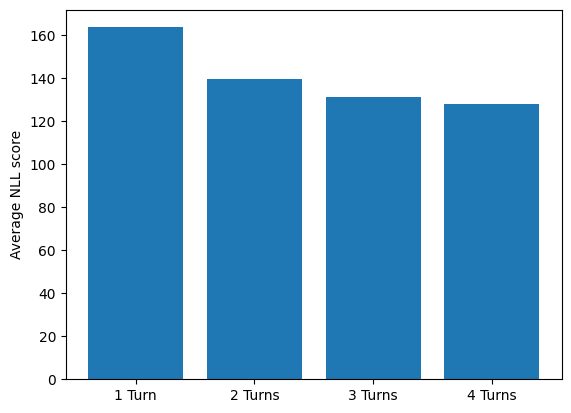

In [4]:
labels = ["1 Turn"] + [f"{i} Turns" for i in range(2, 5)]
plt.bar(labels, [nll_scores[f"logprob_turns_{i}"] for i in range(1, 5)])
plt.ylabel("Average NLL score")
plt.show()

## 5 Turns

### Human only

In [3]:
turns = 5
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

NameError: name 'read_results' is not defined

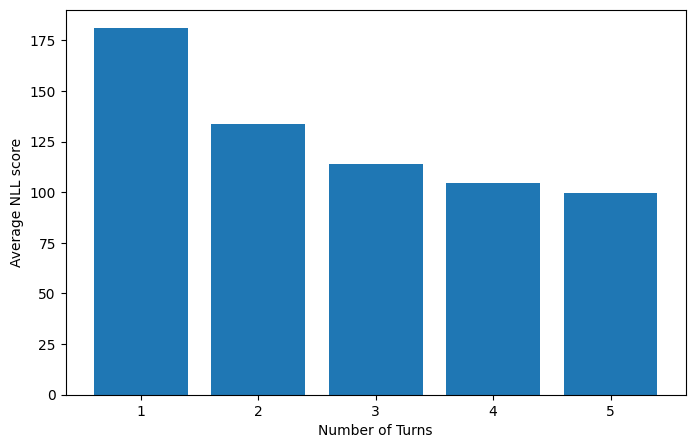

In [36]:
bar_chart(avg_nll_scores, turns, nll=True)

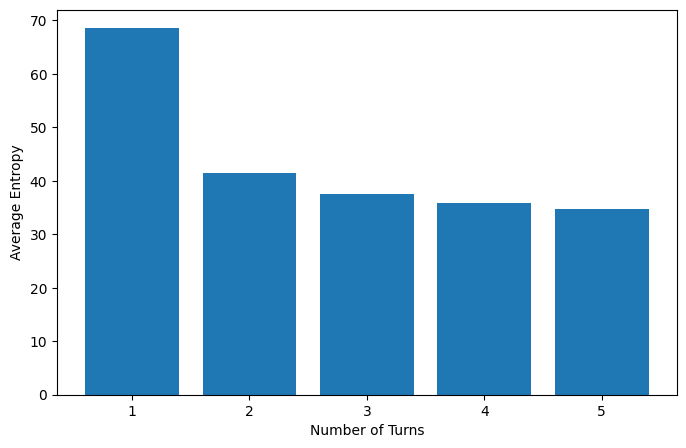

In [37]:
bar_chart(avg_entropy, turns, nll=False)

### Model only

In [7]:
turns = 5
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

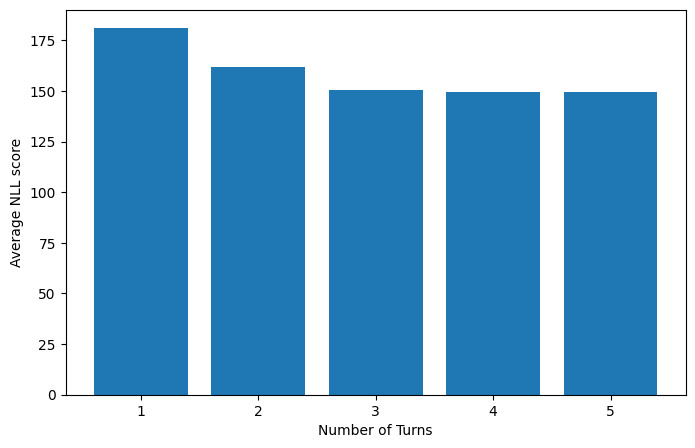

In [8]:
bar_chart(avg_nll_scores)

## 6 Turns

In [ ]:
turns = 6
with open(os.path.join("..", "results", "6_multi_turn_logprobs.json"), "r") as f:
    multi_turn_results = json.load(f)
turn_scores = defaultdict(list)

for entry in multi_turn_results:
    for turn in range(1, 7):
        turn_key = f"logprob_turns_{turn}"
        turn_scores[turn_key].append(entry[turn_key])

# Calculate average log probabilities per turn
avg_turn_scores = {turn: np.mean(scores) for turn, scores in turn_scores.items()}

# Flip sign for NLL
nll_scores = {turn: -score for turn, score in avg_turn_scores.items()}

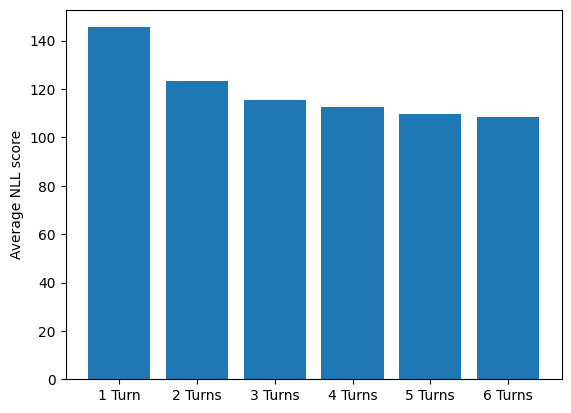

In [9]:
labels = ["1 Turn"] + [f"{i} Turns" for i in range(2, 7)]
plt.bar(labels, [nll_scores[f"logprob_turns_{i}"] for i in range(1, 7)])
plt.ylabel("Average NLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_{turns}_turn_nll_scores.png"))
plt.show()

## 10 Turns

### All messages

In [40]:
turns = 10
human_only = False
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

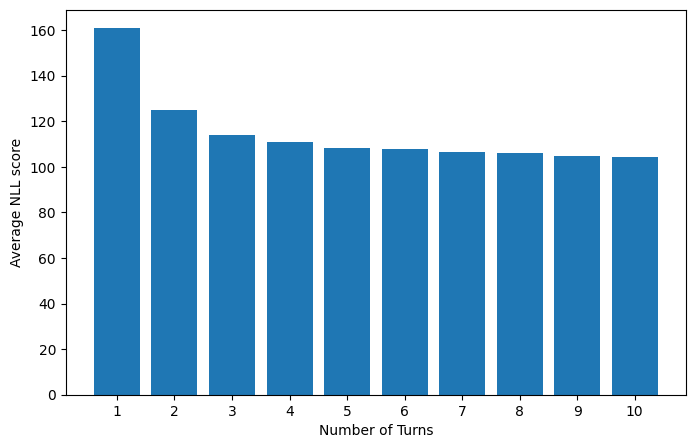

In [42]:
bar_chart(avg_nll_scores, turns)

### Human Only

In [43]:
turns = 10
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

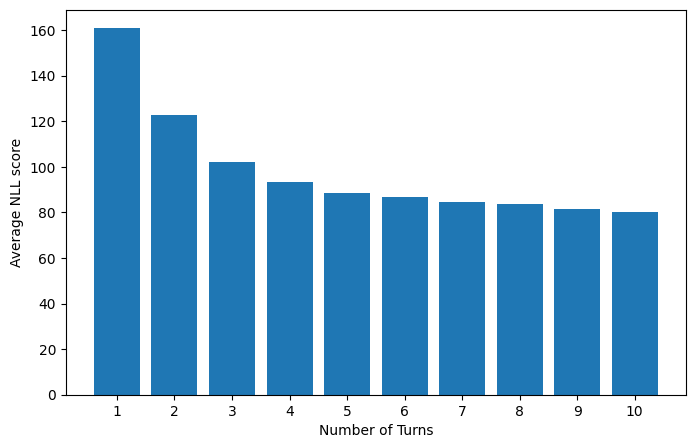

In [44]:
bar_chart(avg_nll_scores, turns)

### Model only

In [5]:
turns = 10
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

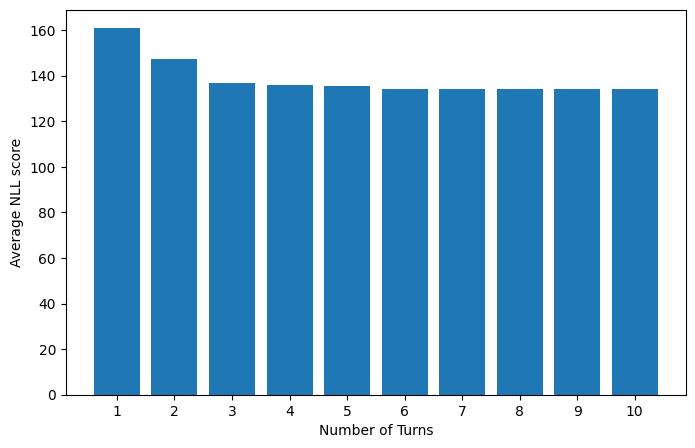

In [6]:
bar_chart(avg_nll_scores)

## 15 Turns

In [46]:
turns = 15
human_only = False
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

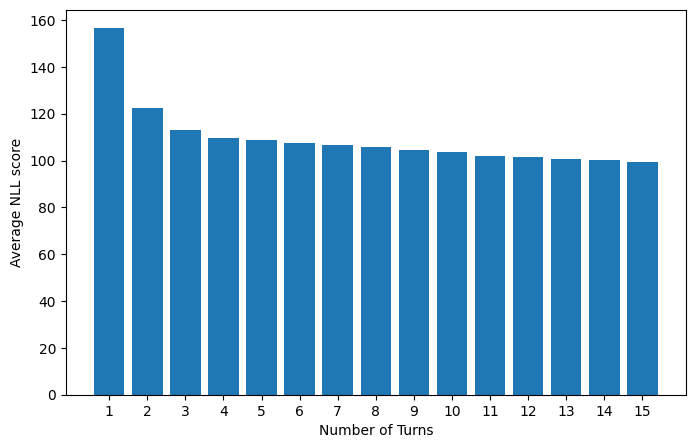

In [47]:
bar_chart(avg_nll_scores, turns)

## 20 Turns

### Human Only

In [48]:
turns = 20
human_only = True
model_only = False
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

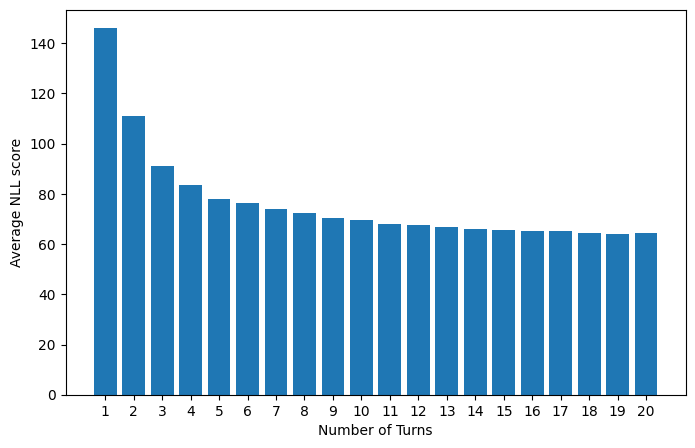

In [49]:
bar_chart(avg_nll_scores, turns)

### Model only

In [65]:
turns = 20
human_only = False
model_only = True
test_human_message = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=True)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

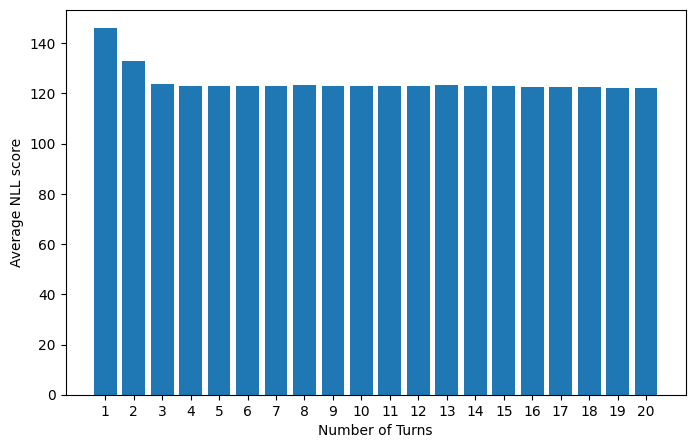

In [66]:
bar_chart(avg_nll_scores)

# Combine multiple experiments in one plot

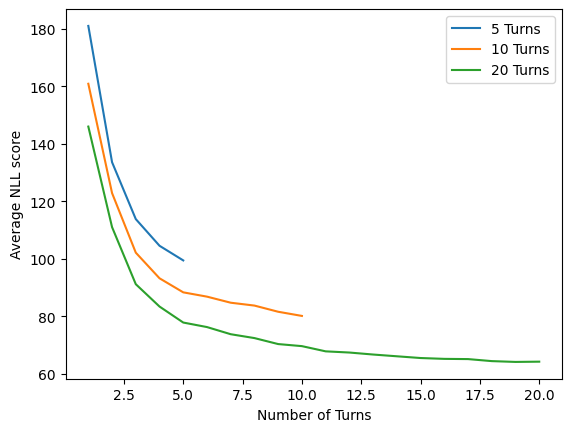

In [ ]:
human_only = True
model_only = False
test_human_message = True

results = dict()
for num_turns in [5, 10, 20]:
    multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=True)
    avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
    plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=f"{num_turns} Turns")
plt.xlabel("Number of Turns")
plt.ylabel("Average NLL score")
plt.legend()
plt.show()

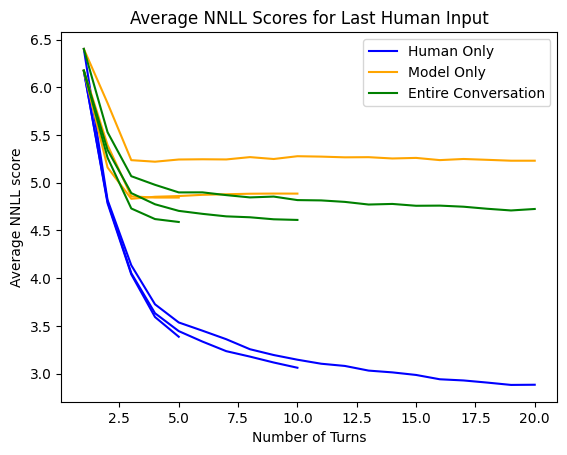

In [82]:
test_human_message = True
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Entire Conversation"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average NNLL score")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH.png"))
plt.show()

# Score last model answer

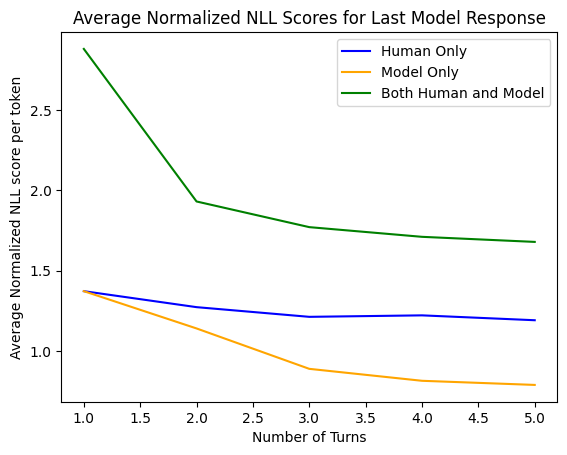

In [14]:
test_human_message = False
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Both Human and Model"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Model Response")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average Normalized NLL score per token")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_model{normalized_setting}.png"))
plt.show()

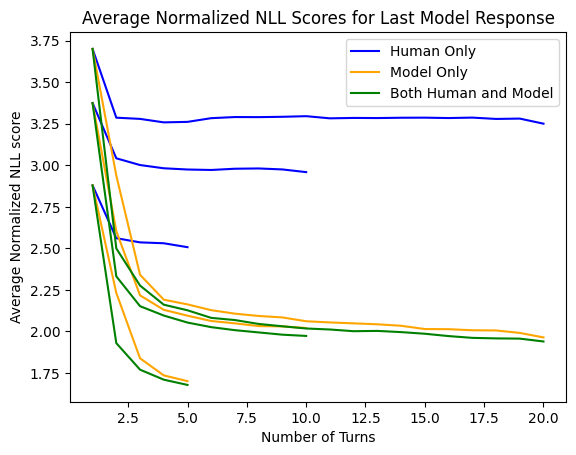

In [49]:
test_human_message = False
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Both Human and Model"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Model Response")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average Normalized NLL score")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_model{normalized_setting}.png"))
plt.show()

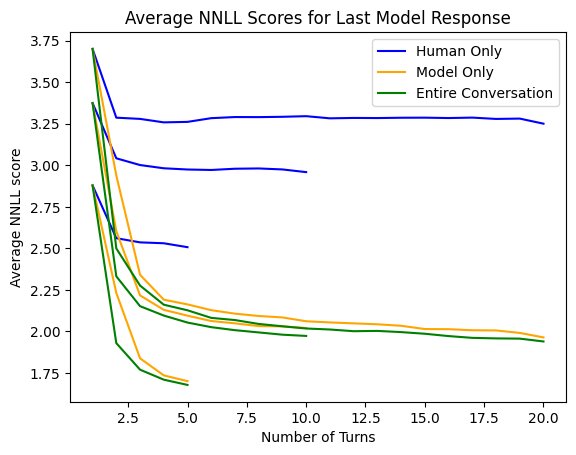

In [81]:
test_human_message = False
normalize = True

results = dict()
for human_only in [True, False, None]:
    if human_only is None:
        model_only = False
        human_only = False
        label = "Entire Conversation"
        color = "green"
    else:
      model_only = not human_only
      label = "Human Only" if human_only else "Model Only"
      color = "blue" if human_only else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Model Response")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average NNLL score")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM.png"))
plt.show()

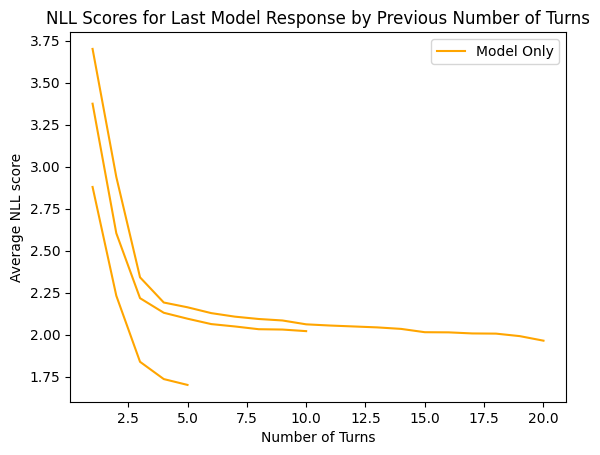

In [39]:
test_human_message = False
normalize = True

results = dict()
model_only = True
human_only = False
label = "Human Only" if human_only else "Model Only"
color = "blue" if human_only else "orange"
for num_turns in [5, 10, 20]:
    multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, normalize=normalize)
    avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
    plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_model.png"))
plt.show()

Investigate spike at 2 turns

In [201]:
turns = 20
human_only = False
model_only = True
test_human_message = False
inject_random_turn = False

In [210]:
normalize = True
multi_turn_results_norm = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn, normalize=normalize)
normalize = False
multi_turn_results_no = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn, normalize=normalize)
# avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

# conversation_ids = set([entry["conversation_id"] for entry in multi_turn_results_norm])
# multi_turn_results_no = [entry for entry in multi_turn_results_no if entry["conversation_id"] in conversation_ids]

In [211]:
avg_nll_scores_no = average_results(multi_turn_results_no, turns, return_nll=True)[0]
avg_nll_scores_norm = average_results(multi_turn_results_norm, turns, return_nll=True)[0]

In [212]:
for key in avg_nll_scores_no.keys():
    print(f"{key}: {avg_nll_scores_norm[key] / avg_nll_scores_no[key]} ")

logprob_turns_1: 0.008204648335115477 
logprob_turns_2: 0.009986810648326969 
logprob_turns_3: 0.008269034989788126 
logprob_turns_4: 0.007887318985079045 
logprob_turns_5: 0.007894528766371478 
logprob_turns_6: 0.008065110636560766 
logprob_turns_7: 0.008007592169619106 
logprob_turns_8: 0.007879440896696632 
logprob_turns_9: 0.0078526053084257 
logprob_turns_10: 0.007839104469103603 
logprob_turns_11: 0.007824627986629343 
logprob_turns_12: 0.007870522601180879 
logprob_turns_13: 0.007824935082714245 
logprob_turns_14: 0.007871945556792893 
logprob_turns_15: 0.0077898946994978645 
logprob_turns_16: 0.007817933346803668 
logprob_turns_17: 0.0077858989568248636 
logprob_turns_18: 0.00784784531649342 
logprob_turns_19: 0.00776130490467289 
logprob_turns_20: 0.007615161132788925 


# Inject Random Turn

### 5 Turns

In [214]:
turns = 5
human_only = True
model_only = False
test_human_message = True
inject_random_turn = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

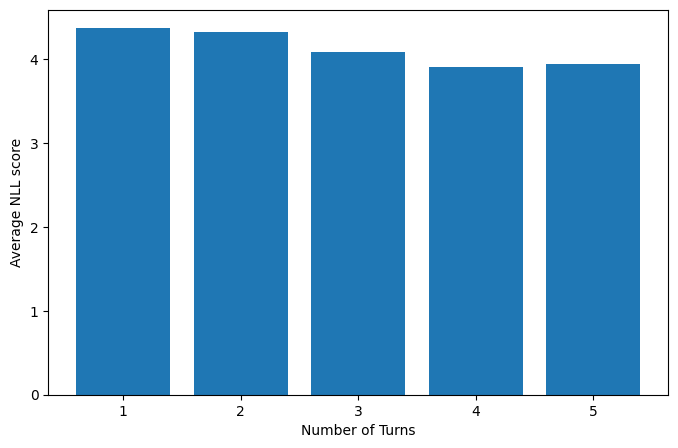

In [215]:
bar_chart(avg_nll_scores)

### 10 Turns

In [8]:
turns = 10
human_only = True
model_only = False
test_human_message = True
inject_random_turn = True
multi_turn_results = read_results(turns, human_only, model_only, test_human_message=test_human_message, random_turn=inject_random_turn)
avg_nll_scores, avg_entropy = average_results(multi_turn_results, turns, return_nll=True)

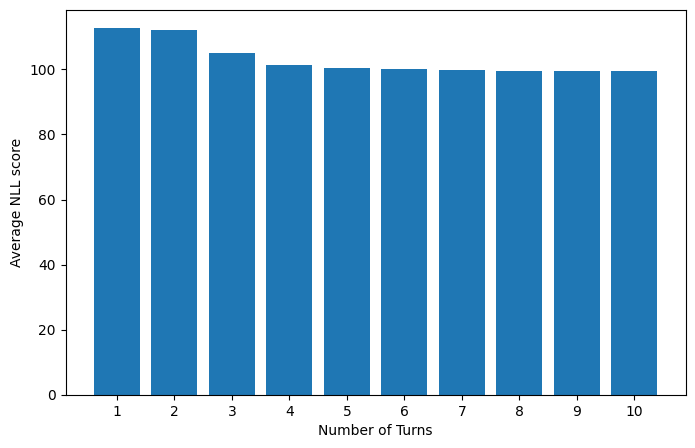

In [9]:
bar_chart(avg_nll_scores)

### Plot comparing to baseline

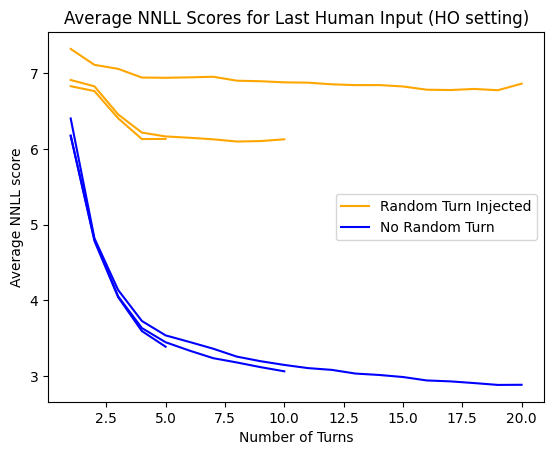

In [60]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for random_turn in [True, False]:
    label = "Random Turn Injected" if random_turn else "No Random Turn"
    color = "orange" if random_turn else "blue"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, random_turn=random_turn)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Human Input (HO setting)")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_random_turn.png"))
plt.show()

# Investigator setting

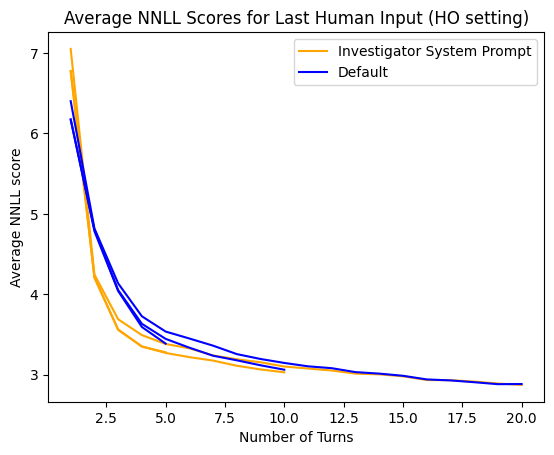

In [61]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for investigator in [True, False]:
    label = "Investigator System Prompt" if investigator else "Default"
    color = "orange" if investigator else "blue"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, investigator=investigator)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Human Input (HO setting)")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

# Use Native Model

In [15]:
avg_nll_scores

{'logprob_turns_1': 240.27453482877172,
 'logprob_turns_2': 218.43070241279915,
 'logprob_turns_3': 235.543840172041,
 'logprob_turns_4': 245.31957351103452,
 'logprob_turns_5': 254.47765990599407,
 'logprob_turns_6': 264.14656595939357,
 'logprob_turns_7': 265.72450831714616,
 'logprob_turns_8': 277.6040628269911,
 'logprob_turns_9': 305.5987210424499,
 'logprob_turns_10': 356.583320408675}

In [20]:
logprob_10 = [result["logprob_turns_10"] for result in multi_turn_results]
mean = np.mean(logprob_10)

In [24]:
for result in multi_turn_results:
    if abs(result["logprob_turns_10"] - mean) > 500:
        print(result["logprob_turns_10"])

-3501.980624973774
-4141.176972389221
-3685.2241230756044
-1084.9597802199423
-7000.067098617554
-1620.88954984257
-4769.057696700096
-3975.8195273913443
-1880.52305996418
-2226.8210873133503
-57186.466022372246
-3909.3114453181624
-5089.586242992373
-1793.2334516020492
-1176.2179522514343
-1146.973310041707
-1703.0177915096283
-866.9976890999824
-2071.378961086273
-930.611674785614
-1594.6046329292037
-7697.1979521512985
-3096.5638442486525
-3203.7021490391344


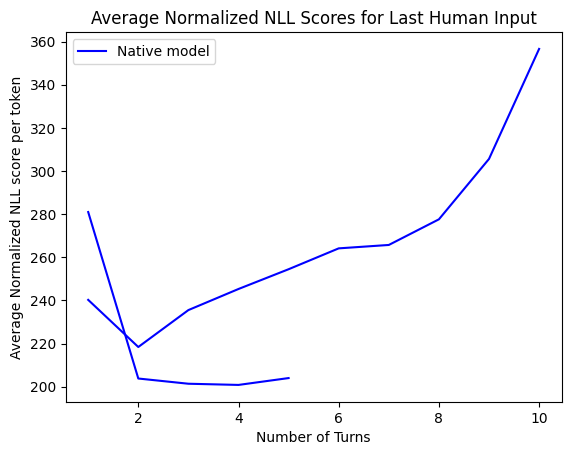

In [14]:
test_human_message = False
human_only = False
model_only = False
results = dict()
for native_model in [True]:
    label = "Native model" if native_model else "Qwen3-8B"
    color = "blue" if native_model else "orange"
    for num_turns in [5, 10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, normalize=False)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

Something goes wrong as number of turns increase. Maybe Chat Template?

# Mix user input

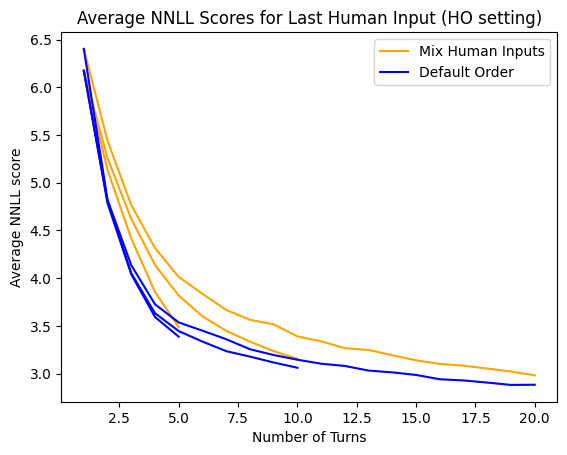

In [63]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for mix_inputs in [True, False]:
    label = "Mix Human Inputs" if mix_inputs else "Default Order"
    color = "orange" if mix_inputs else "blue"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, mix_inputs=mix_inputs)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Human Input (HO setting)")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_mix_inputs.png"))
plt.show()

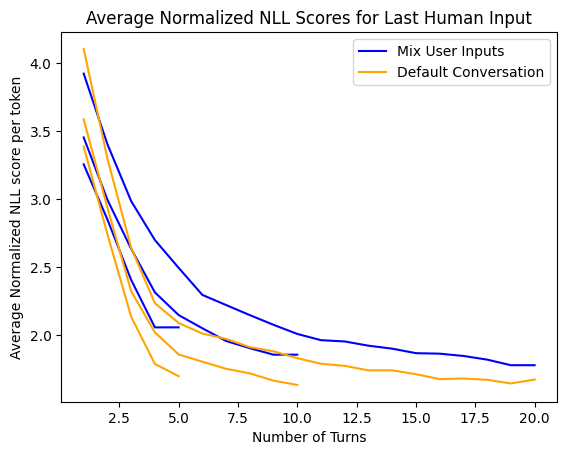

In [13]:
test_human_message = True
human_only = True
model_only = False
results = dict()
for mix_inputs in [True, False]:
    label = "Mix User Inputs" if mix_inputs else "Default Conversation"
    color = "blue" if mix_inputs else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, mix_inputs=mix_inputs)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_investigator.png"))
plt.show()

# Clear Assistant Message

this is the same as human-only, but with assistant tokens

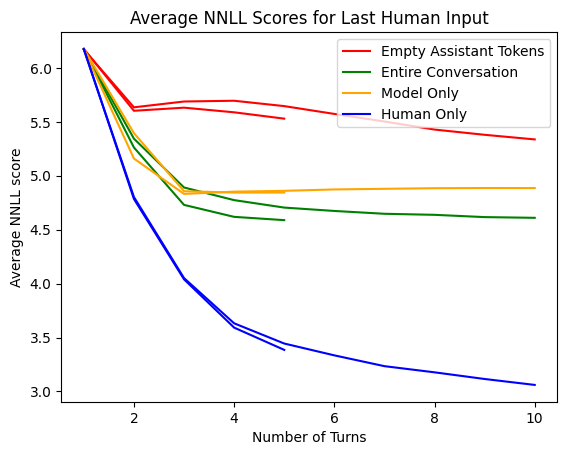

In [83]:
test_human_message = True
human_only = False
model_only = False
results = dict()
for empty_assistant in [True, False, None, "HO"]:
    if empty_assistant is None:
        model_only = True
        label = "Model Only"
        color = "orange"
    elif empty_assistant == "HO":
        model_only = False
        human_only = True
        empty_assistant = None
        label = "Human Only"
        color = "blue"
    else:
      label = "Empty Assistant Tokens" if empty_assistant else "Entire Conversation"
      color = "red" if empty_assistant else "green"
    for num_turns in [5, 10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, empty_assistant=empty_assistant)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average NNLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_empty_assistant.png"))
plt.show()

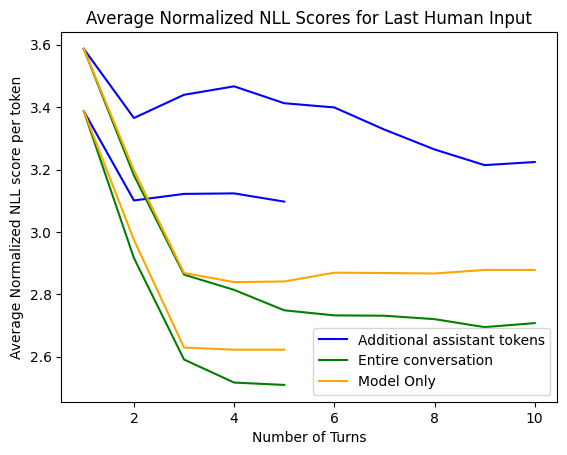

In [32]:
test_human_message = True
human_only = False
model_only = False
results = dict()
for empty_assistant in [True, False, None]:
    if empty_assistant is None:
        model_only = False
        model_only = True
        label = "Model Only"
        color = "orange"
    else:
      label = "Additional assistant tokens" if empty_assistant else "Entire conversation"
      color = "blue" if empty_assistant else "green"
    for num_turns in [5, 10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, empty_assistant=empty_assistant)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_empty_assistant.png"))
plt.show()

# TM vs TH in one plot

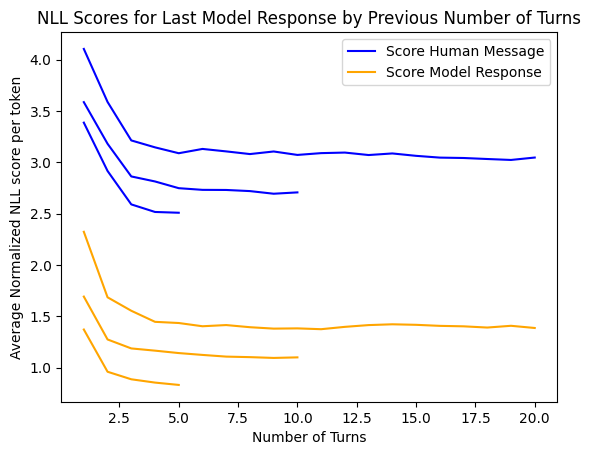

In [29]:
human_only = False
model_only = False
results = dict()
for test_human_message in [True, False]:
    label = "Score Human Message" if test_human_message else "Score Model Response"
    color = "blue" if test_human_message else "orange"
    for num_turns in [5, 10, 20]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)
        avg_nll_scores, avg_entropy = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_vs_TM.png"))
plt.show()

# Compare Mean Token Rankings

In [28]:
for num_turns in [5, 10, 20]:
    multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)
    avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
    print(f"{num_turns} Turns - Mean Rank: {avg_rankings[f'mean_rank_turns_{num_turns}']}")

5 Turns - Mean Rank: 222.34561341199344
10 Turns - Mean Rank: 222.5793564668987
20 Turns - Mean Rank: 156.79607180633212


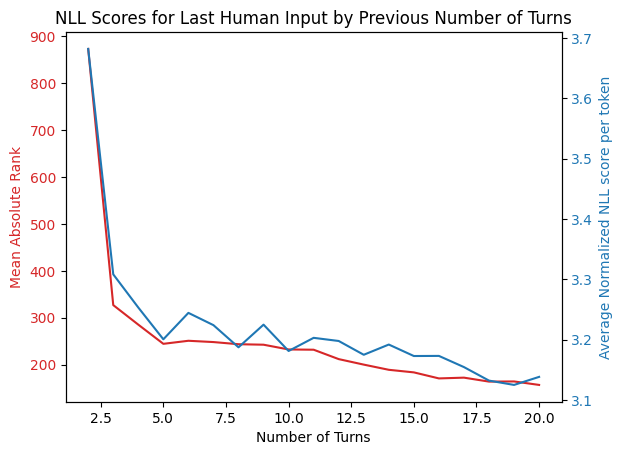

In [32]:
human_only = False
model_only = False
test_human_message = True
num_turns = 20

labels = range(2, num_turns + 1)
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Number of Turns')
ax1.set_ylabel('Mean Absolute Rank', color=color)
multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
ax1.plot(labels, [avg_rankings[f"mean_rank_turns_{i}"] for i in range(2, num_turns + 1)], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Average Normalized NLL score per token', color=color)  # we already handled the x-label with ax1
multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)
avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
ax2.plot(labels, [avg_nll_scores[f"logprob_turns_{i}"] for i in range(2, num_turns + 1)], color=color)
ax2.tick_params(axis='y', labelcolor=color)

# fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title("NLL Scores for Last Human Input by Previous Number of Turns")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_mean_rank.png"))
plt.show()

# Compare Template A

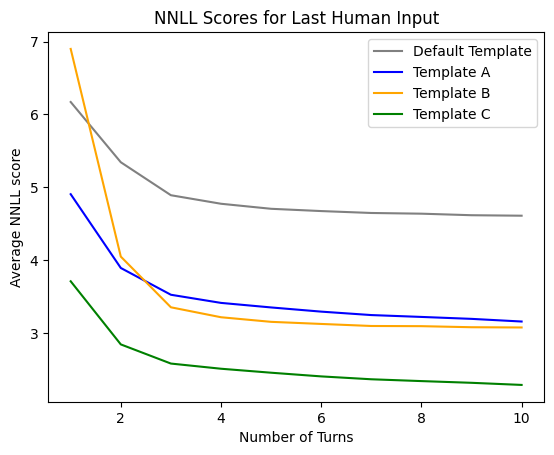

In [68]:
human_only = False
model_only = False
test_human_message = True

for template_type in [None, "A", "B", "C"]:
    label = "Template A" if template_type == "A" else "Template B" if template_type == "B" else "Template C" if template_type == "C" else "Default Template"
    color = "blue" if template_type == "A" else "orange" if template_type == "B" else "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NNLL Scores for Last Human Input")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_templates.png"))
plt.show()

# Template C with Test Model Message

### Individual

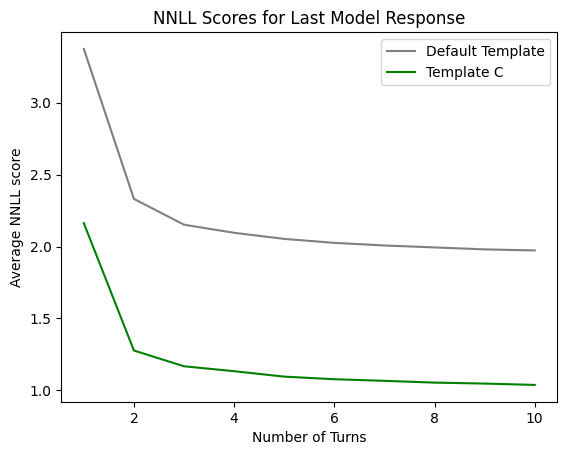

In [69]:
human_only = False
model_only = False
test_human_message = False

for template_type in [None, "C"]:
    label = "Template A" if template_type == "A" else "Template B" if template_type == "B" else "Template C" if template_type == "C" else "Default Template"
    color = "blue" if template_type == "A" else "orange" if template_type == "B" else "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NNLL Scores for Last Model Response")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_TC.png"))
plt.show()

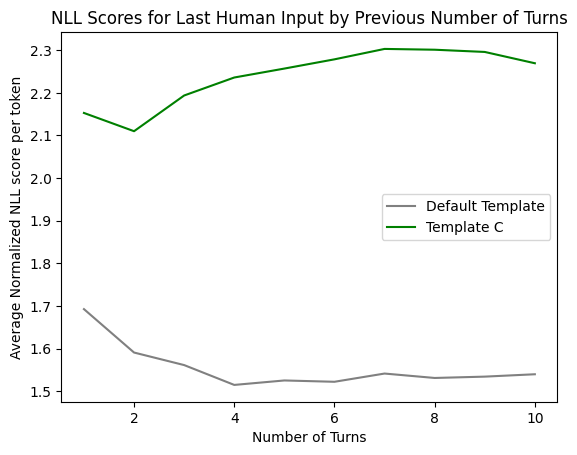

In [8]:
human_only = True
model_only = False
test_human_message = False

for template_type in [None, "C"]:
    label = "Template A" if template_type == "A" else "Template B" if template_type == "B" else "Template C" if template_type == "C" else "Default Template"
    color = "blue" if template_type == "A" else "orange" if template_type == "B" else "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Human Input by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_templates.png"))
plt.show()

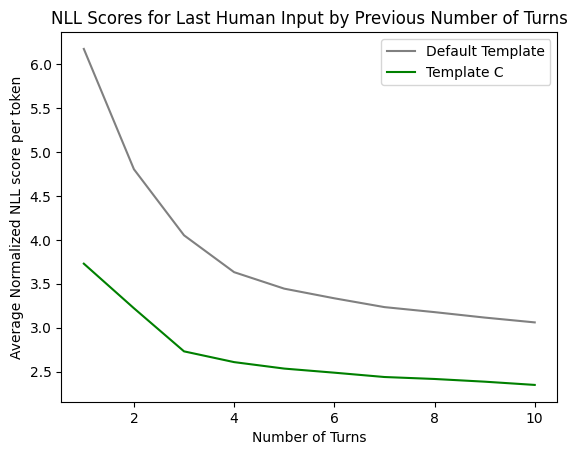

In [9]:
human_only = True
model_only = False
test_human_message = True

for template_type in [None, "C"]:
    label = "Template A" if template_type == "A" else "Template B" if template_type == "B" else "Template C" if template_type == "C" else "Default Template"
    color = "blue" if template_type == "A" else "orange" if template_type == "B" else "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Human Input by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_templates.png"))
plt.show()

## Model Only

TH

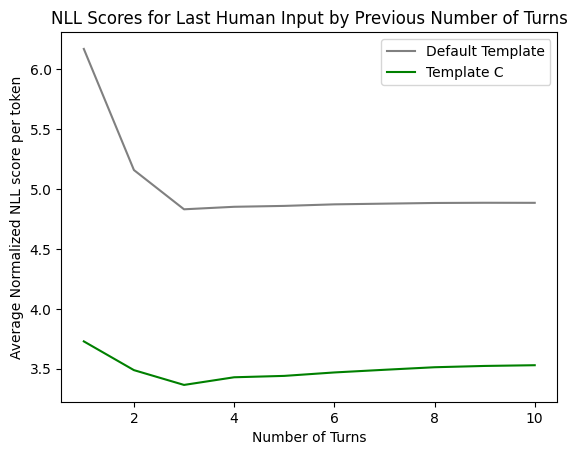

In [ ]:
human_only = False
model_only = True
test_human_message = True

for template_type in [None, "C"]:
    label = "Template C" if template_type == "C" else "Default Template"
    color = "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Human Input by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_templates.png"))
plt.show()

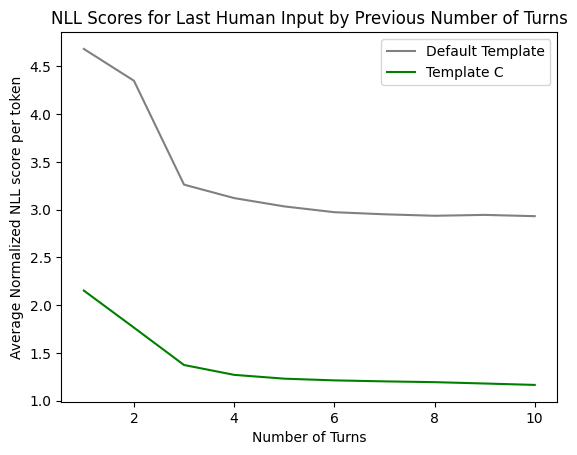

In [ ]:
human_only = False
model_only = True
test_human_message = False

for template_type in [None, "C"]:
    label = "Template C" if template_type == "C" else "Default Template"
    color = "green" if template_type == "C" else "gray"
    for num_turns in [10]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
        avg_nll_scores, avg_entropy, avg_rankings = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Human Input by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_templates.png"))
plt.show()

# Finalize Template C plots

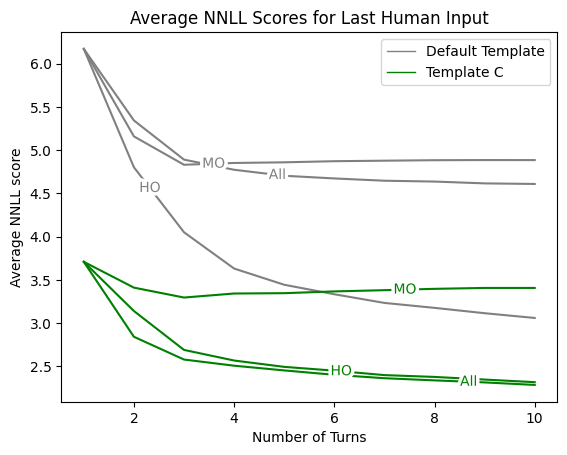

In [80]:
from labellines import labelLines
test_human_message = True

results = dict()
labels = []
for template_type in [None, "C"]:
  for human_only in [True, False, None]:
      if human_only is None:
          model_only = False
          human_only = False
          label = "All"
      else:
        model_only = not human_only
        label = "HO" if human_only else "MO"
      color = "green" if template_type == "C" else "gray"
      for num_turns in [10]:
          multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
          avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
          plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label, color=color)
          labels.append(label)

newLabels = ["Default Template", "Template C"]
custom_Handles = [Line2D([0], [0], color="gray", lw=1),
                Line2D([0], [0], color="green", lw=1),]

labelLines(plt.gca().get_lines(), align=False)
plt.title("Average NNLL Scores for Last Human Input")
plt.legend(custom_Handles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average NNLL score")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_TC.png"))
plt.show()

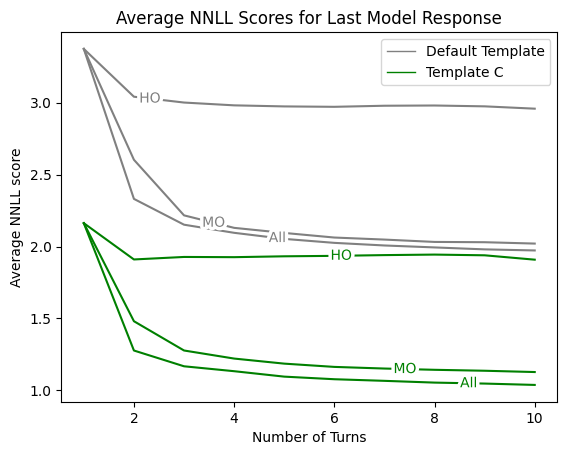

In [79]:
from labellines import labelLines
test_human_message = False

results = dict()
labels = []
for template_type in [None, "C"]:
  for human_only in [True, False, None]:
      if human_only is None:
          model_only = False
          human_only = False
          label = "All"
      else:
        model_only = not human_only
        label = "HO" if human_only else "MO"
      color = "green" if template_type == "C" else "gray"
      for num_turns in [10]:
          multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, template_type=template_type)
          avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
          plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label, color=color)
          labels.append(label)

newLabels = ["Default Template", "Template C"]
custom_Handles = [Line2D([0], [0], color="gray", lw=1),
                Line2D([0], [0], color="green", lw=1),]

labelLines(plt.gca().get_lines(), align=False)
plt.title("Average NNLL Scores for Last Model Response")
plt.legend(custom_Handles, newLabels) 
plt.xlabel("Number of Turns")
if normalize:
    plt.ylabel("Average NNLL score")
else:
  plt.ylabel("Average NLL score")
normalized_setting = "_norm" if normalize else ""
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TM_TC.png"))
plt.show()

# Low Tokens

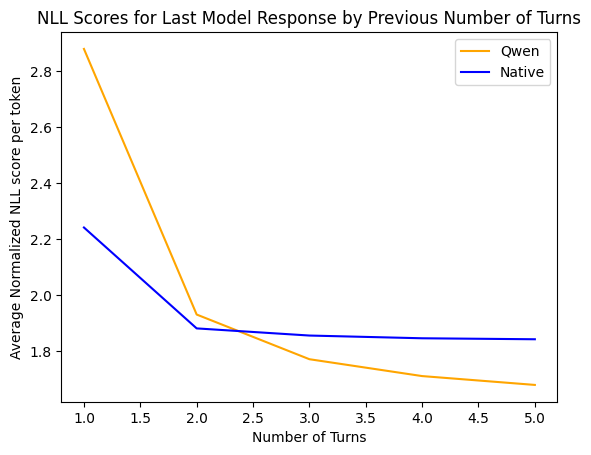

In [20]:
test_human_message = False
human_only = False
model_only = False

results = dict()
for native_model in [False, True]:
    label = "Native" if native_model else "Qwen"
    color = "blue" if native_model else "orange"
    low_tokens = native_model
    # template_type = None if native_model else "C"
    for num_turns in [5]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, low_tokens=low_tokens, template_type=None)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_vs_TM.png"))
plt.show()

In [15]:
num_turns = 5
multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=True, low_tokens=True)

In [21]:
qwen_multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message)

In [58]:
native_ids = [res["conversation_id"] for res in multi_turn_results]
count = 0
lengths = []
ratios = []
for qwen, native in zip(qwen_multi_turn_results, multi_turn_results):
    if qwen["conversation_id"] not in native_ids:
        continue

    if abs(qwen["logprob_turns_1"]) > 2 * abs(native["logprob_turns_1"]):
        ratios.append(abs(qwen["logprob_turns_5"]) / abs(native["logprob_turns_5"])) 
        count += 1
        lengths.append(native["total_length"])

In [59]:
count

97

In [60]:
avg_length = np.mean([res["total_length"] for res in multi_turn_results])
avg_length

1330.905723905724

In [61]:
np.mean(lengths)

1486.3298969072166

In [63]:
median_five = np.median([res["logprob_turns_5"] for res in multi_turn_results])

In [ ]:
qwen_median_five = np.median([res["logprob_turns_5"] for res in qwen_multi_turn_results])
median_five, qwen_median_five

(-1.092904796214241, -1.3126032946543713)

# LLM Generated Transcripts

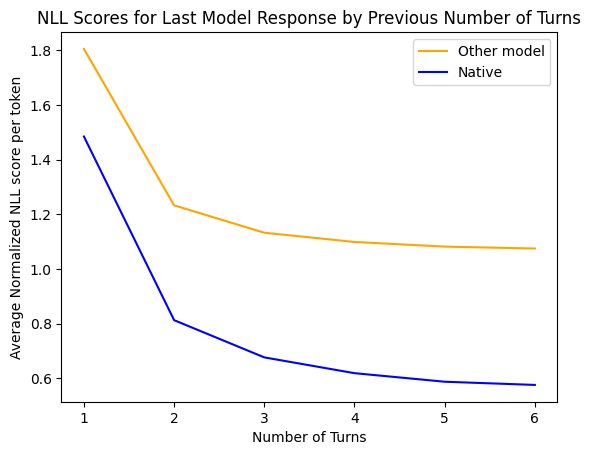

In [11]:
test_human_message = False
human_only = False
model_only = False
low_tokens= True

results = dict()
for native_model in [False, True]:
    label = "Native" if native_model else "Other model"
    color = "blue" if native_model else "orange"
    # template_type = None if native_model else "C"
    for num_turns in [6]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, low_tokens=low_tokens, template_type=None)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("NLL Scores for Last Model Response by Previous Number of Turns")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_vs_TM.png"))
plt.show()

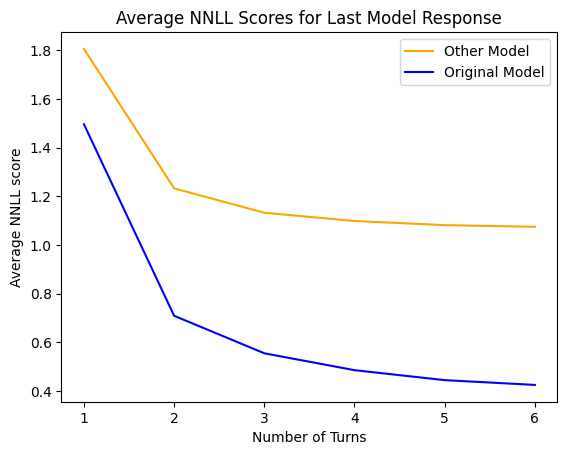

In [11]:
test_human_message = False
human_only = False
model_only = False
low_tokens= True

results = dict()
for native_model in [False, True]:
    label = "Original Model" if native_model else "Other Model"
    color = "blue" if native_model else "orange"
    # template_type = None if native_model else "C"
    for num_turns in [6]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, low_tokens=low_tokens)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("Average NNLL Scores for Last Model Response")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_original.png"))
plt.show()

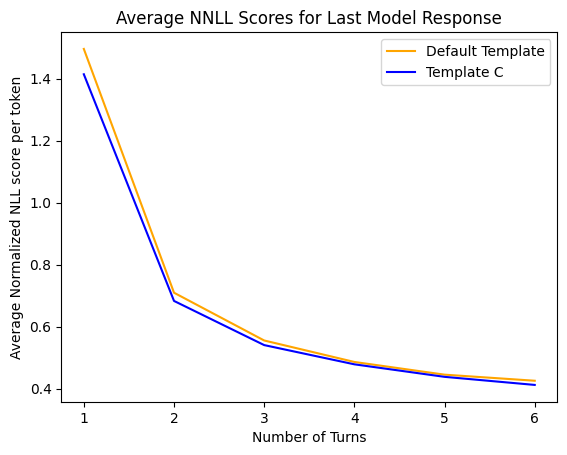

In [12]:
test_human_message = False
human_only = False
model_only = False
low_tokens= True

results = dict()
native_model = True
for template_type in [None, "C"]:
    label = "Template C" if template_type else "Default Template"
    color = "blue" if template_type else "orange"
    # template_type = None if native_model else "C"
    for num_turns in [6]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model=native_model, low_tokens=low_tokens, template_type=template_type)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label,color=color)

plt.title("Average NNLL Scores for Last Model Response")
handles, labels = plt.gca().get_legend_handles_labels()
newLabels, newHandles = [], []
for handle, label in zip(handles, labels):
  if label not in newLabels:
    newLabels.append(label)
    newHandles.append(handle)
# plt.title("Average Normalized NLL Scores for Last Human Input")
plt.legend(newHandles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average Normalized NLL score per token")

plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_TH_vs_TM.png"))
plt.show()

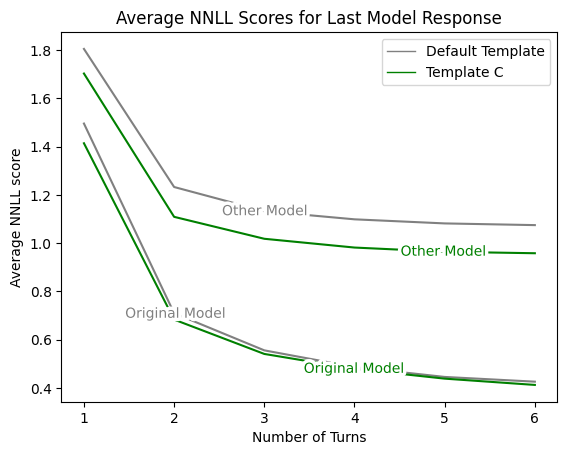

In [13]:
from labellines import labelLines
test_human_message = False

results = dict()
labels = []
human_only = False
model_only = False
low_tokens = True

for template_type in [None, "C"]:
  for native_model in [True, False]:
    label = "Original Model" if native_model else "Other Model"
    color = "green" if template_type == "C" else "gray"
    for num_turns in [6]:
        multi_turn_results = read_results(num_turns, human_only, model_only, test_human_message=test_human_message, native_model = native_model, template_type=template_type, low_tokens=low_tokens)
        avg_nll_scores, avg_entropy, _ = average_results(multi_turn_results, num_turns, return_nll=True)
        plt.plot(range(1, num_turns + 1), [avg_nll_scores[f"logprob_turns_{i}"] for i in range(1, num_turns + 1)], label=label, color=color)
        labels.append(label)

newLabels = ["Default Template", "Template C"]
custom_Handles = [Line2D([0], [0], color="gray", lw=1),
                Line2D([0], [0], color="green", lw=1),]

labelLines(plt.gca().get_lines(), align=False)
plt.title("Average NNLL Scores for Last Model Response")
plt.legend(custom_Handles, newLabels) 
plt.xlabel("Number of Turns")
plt.ylabel("Average NNLL score")
plt.savefig(os.path.join("..", "plots", f"exp_multi_calibration_Original_TC.png"))
plt.show()